In [2]:
from pathlib import Path
import pandas as pd

# Search automatically for the 'train' directory inside Kaggle input
input_root = Path("/kaggle/input")
train_dirs = [p for p in input_root.rglob("train") if p.is_dir()]

if not train_dirs:
    raise FileNotFoundError("Could not find the 'train' folder under /kaggle/input")

# Use the train folder found
data_dir = train_dirs[0]
print(f"Using directory: {data_dir}")

data = []
valid_extensions = {".jpg", ".jpeg", ".png", ".bmp"}

for file_path in data_dir.rglob("*"):
    if file_path.is_file() and file_path.suffix.lower() in valid_extensions:
        label = file_path.parent.name
        
        if "___" in label:
            crop, disease = label.split("___", 1)
        else:
            crop, disease = label, "unknown"
            
        data.append({
            "path": str(file_path),
            "label": label,
            "crop": crop,
            "disease": disease
        })

df = pd.DataFrame(data)
print(f"Total images found: {len(df)}")
df.head()


Using directory: /kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train


KeyboardInterrupt: 

14 crops | 38 classes
count      38.000000
mean     1849.868421
std       105.724315
min      1642.000000
25%      1763.500000
50%      1844.500000
75%      1924.500000
max      2022.000000
Name: count, dtype: float64


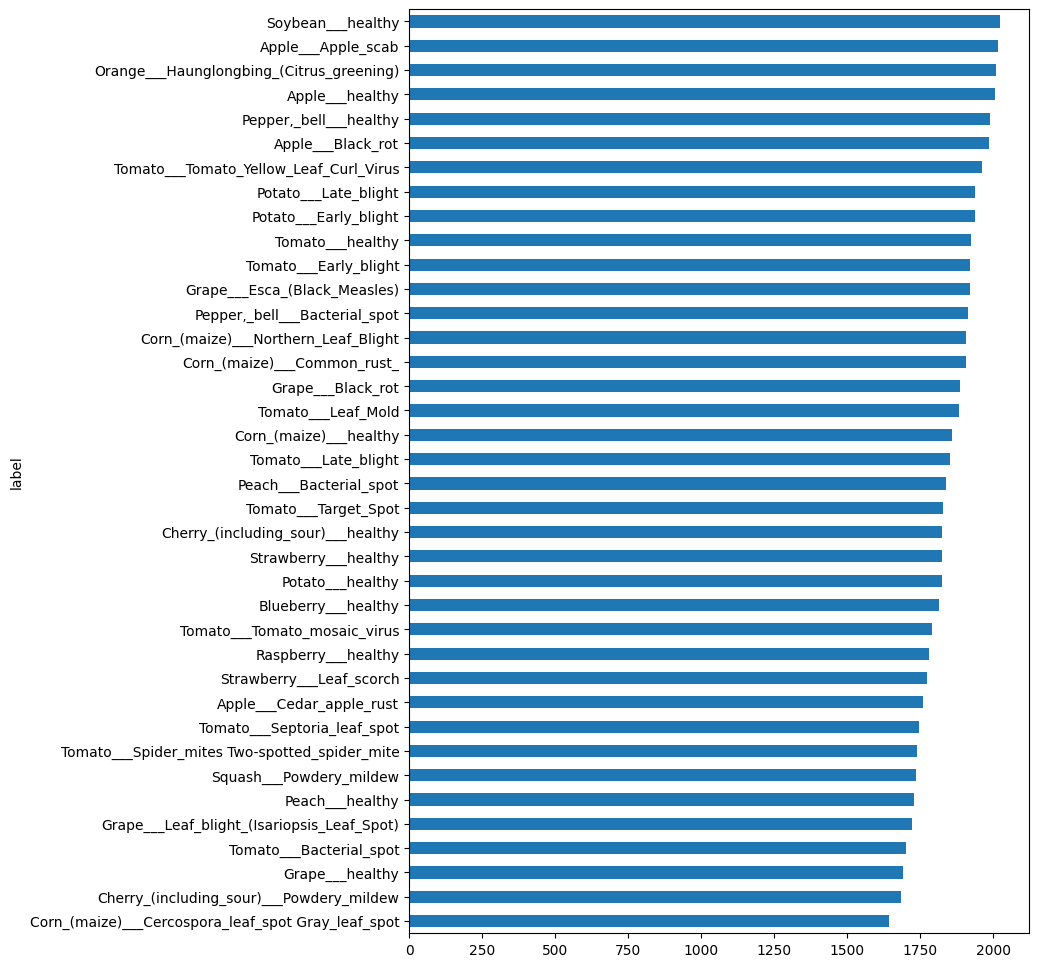

In [3]:
# 1. Clean labels
df["crop"] = df["crop"].str.replace("_", " ").str.strip()
df["disease"] = df["disease"].str.replace("_", " ").str.strip()

# 2. Basic checks
print(df["crop"].nunique(), "crops |", df["label"].nunique(), "classes")
print(df["label"].value_counts().describe())

# 3. Class distribution plot
df["label"].value_counts().sort_values().plot(kind="barh", figsize=(8, 12))

# 4. Save
df.to_csv("metadata.csv", index=False)

(87867, 5) 14 crops


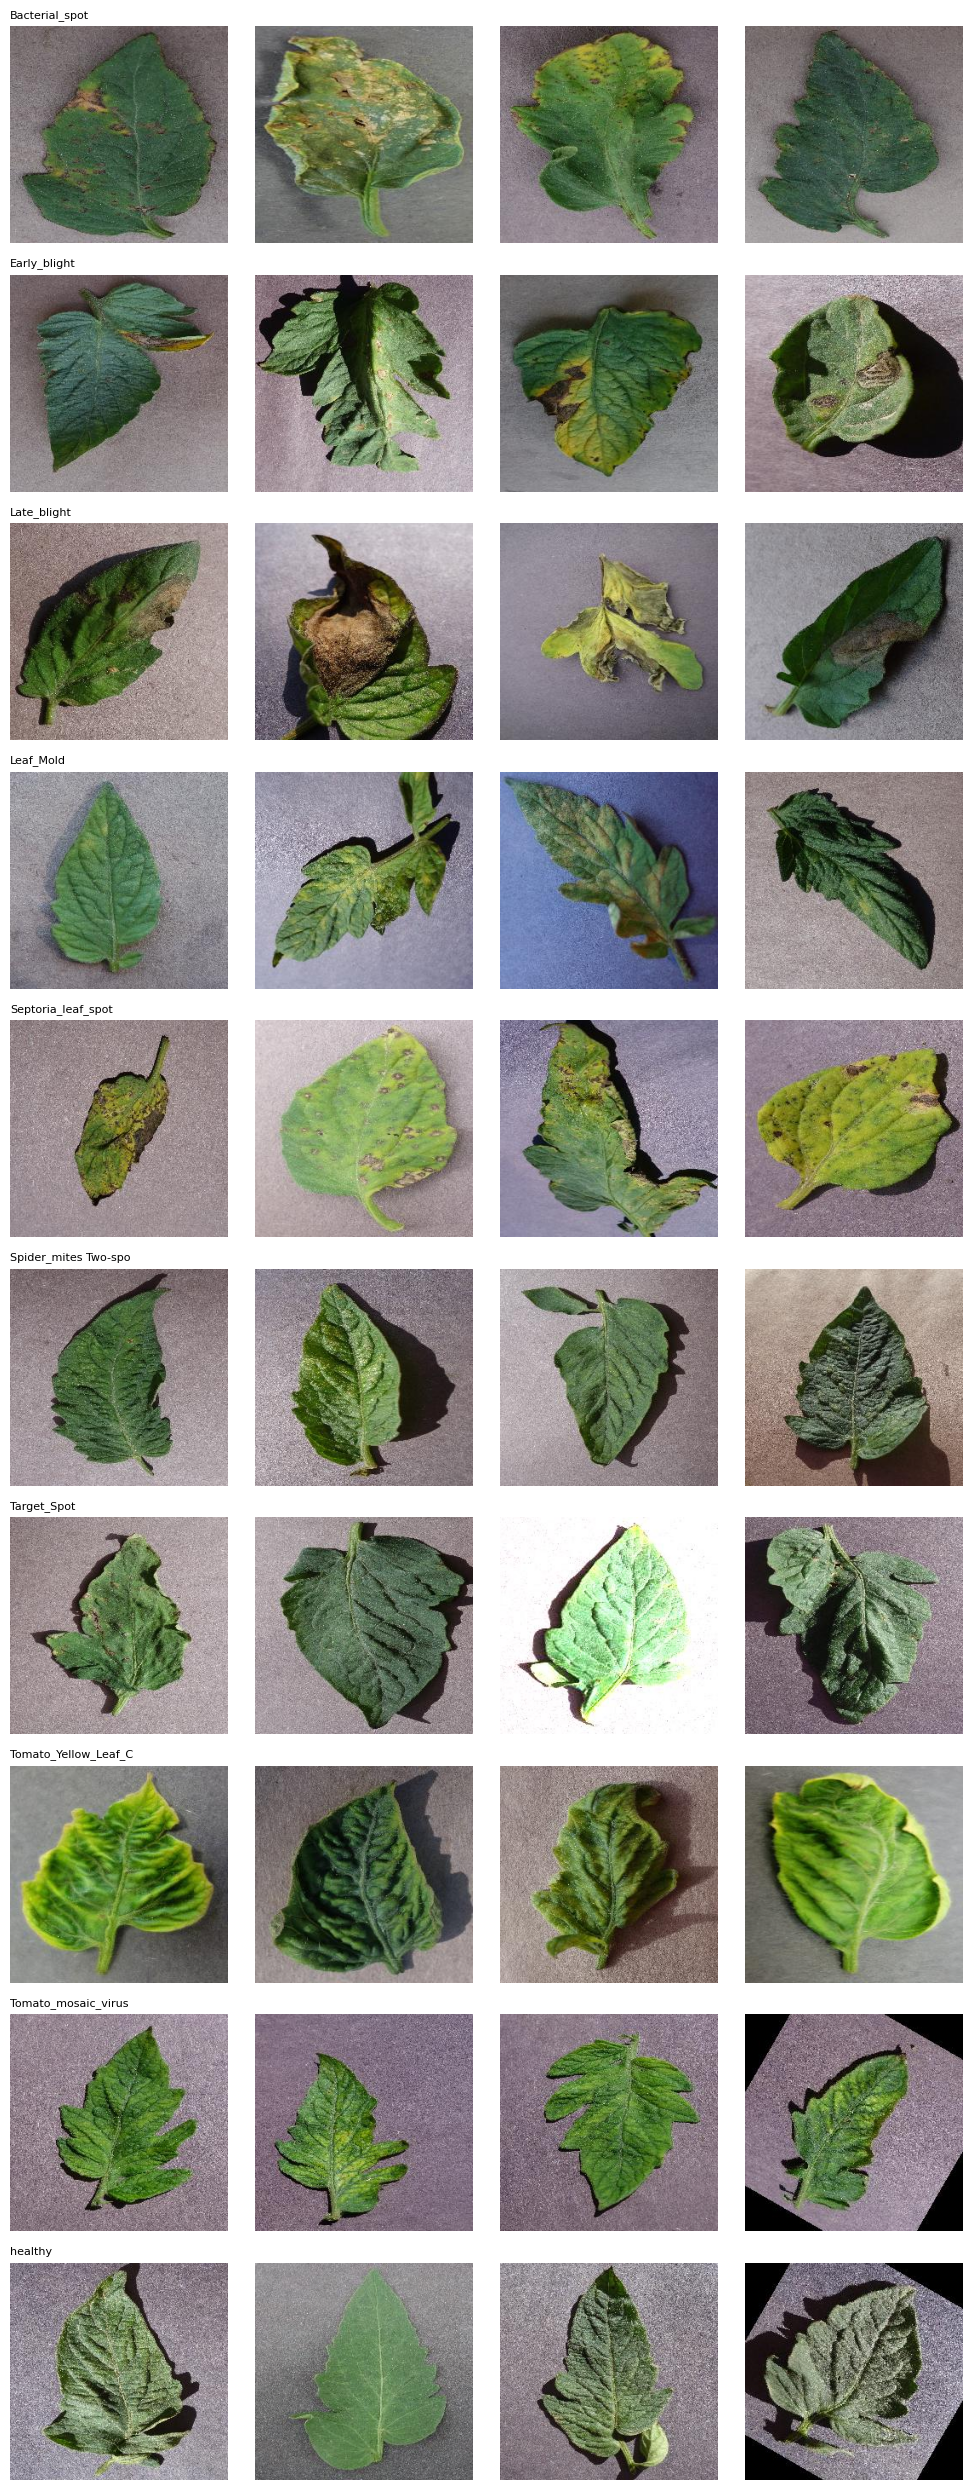

In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# 1. Find the train folder again
input_root = Path("/kaggle/input")
data_dir = [p for p in input_root.rglob("train") if p.is_dir()][0]
valid_dir = data_dir.parent / "valid"

# 2. Rebuild df
def load_split(folder, split_name):
    rows = []
    for p in Path(folder).rglob("*"):
        if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}:
            label = p.parent.name
            crop, disease = label.split("___", 1) if "___" in label else (label, "unknown")
            rows.append({
                "path": str(p),
                "label": label,
                "crop": crop.replace("_", " ").strip(),
                "disease": disease.replace("_", " ").strip(),
                "orig_split": split_name,
            })
    return pd.DataFrame(rows)

df = pd.concat([load_split(data_dir, "train"),
                load_split(valid_dir, "valid")], ignore_index=True)
print(df.shape, df["crop"].nunique(), "crops")

# 3. Grid function
def show_grid(df, crop, n=4):
    labels = sorted(df[df["crop"] == crop]["label"].unique())
    fig, axes = plt.subplots(len(labels), n, figsize=(n * 2.5, len(labels) * 2.5))
    for i, lab in enumerate(labels):
        paths = df[df["label"] == lab].sample(n, random_state=1)["path"]
        for j, p in enumerate(paths):
            axes[i, j].imshow(Image.open(p))
            axes[i, j].axis("off")
            if j == 0:
                axes[i, j].set_title(lab.split("___")[1][:20], fontsize=8, loc="left")
    plt.tight_layout()
    plt.show()

show_grid(df, "Tomato")

In [4]:
df.to_csv("/kaggle/working/metadata.csv", index=False)

In [5]:
print("Saved:", df.shape)

Saved: (87867, 5)


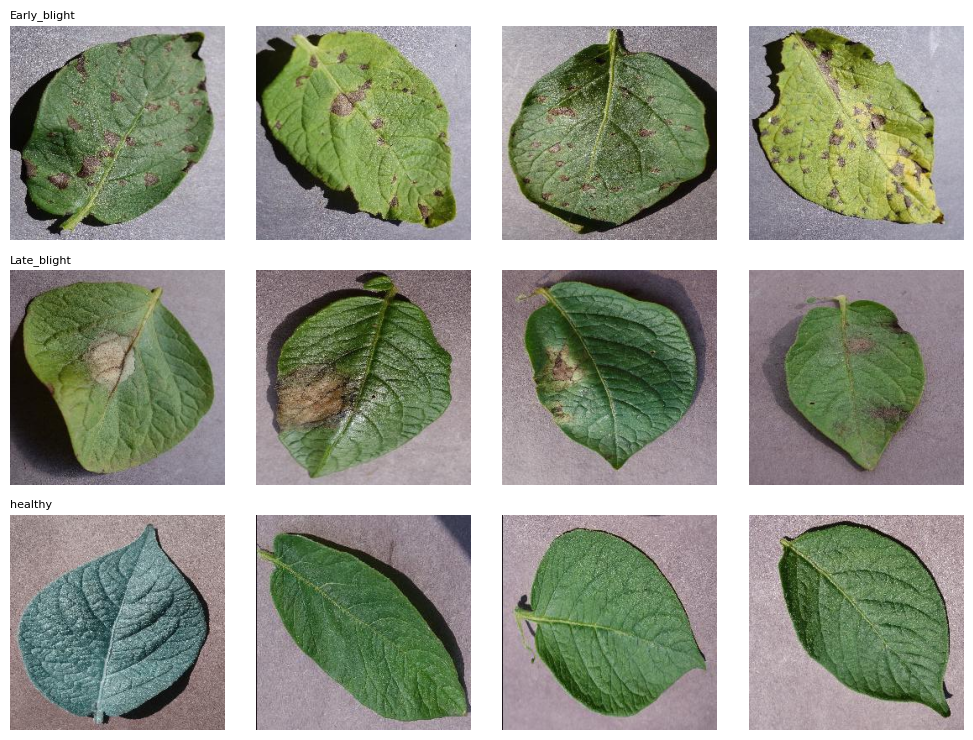

In [6]:
show_grid(df, "Potato")

In [7]:
print(df["crop"].nunique(), "crops |", df["label"].nunique(), "classes")

14 crops | 38 classes


**Hashing and Checking Data Leakage**

In [8]:
import pandas as pd
df = pd.read_csv("/kaggle/working/metadata.csv")
print(df.shape)
df.head()

(87867, 5)


,path,label,crop,disease,orig_split
0,/kaggle/input/datasets/vipoooool/new-plant-dis...,Tomato___Late_blight,Tomato,Late blight,train
1,/kaggle/input/datasets/vipoooool/new-plant-dis...,Tomato___Late_blight,Tomato,Late blight,train
2,/kaggle/input/datasets/vipoooool/new-plant-dis...,Tomato___Late_blight,Tomato,Late blight,train
3,/kaggle/input/datasets/vipoooool/new-plant-dis...,Tomato___Late_blight,Tomato,Late blight,train
4,/kaggle/input/datasets/vipoooool/new-plant-dis...,Tomato___Late_blight,Tomato,Late blight,train


In [9]:
import imagehash
from PIL import Image
from tqdm import tqdm

def compute_hash(path):
    try:
        return str(imagehash.phash(Image.open(path)))
    except Exception:
        return None

# Test on a small sample first (30 seconds)
sample = df.sample(500, random_state=42).copy()
sample["phash"] = [compute_hash(p) for p in tqdm(sample["path"])]
print(sample["phash"].isna().sum(), "failed")

100%|██████████| 500/500 [00:04<00:00, 102.13it/s]

0 failed


working fine so doing it for all the images


In [10]:
tqdm.pandas()
df["phash"] = df["path"].progress_apply(compute_hash)

# Save immediately so you never recompute this
df.to_csv("/kaggle/working/metadata_with_hash.csv", index=False)

100%|██████████| 87867/87867 [12:31<00:00, 117.00it/s]


In [11]:
# Drop any failed hashes
df_clean = df.dropna(subset=["phash"]).copy()

# Group ID = the hash itself (images sharing a hash are "the same leaf")
df_clean["group_id"] = df_clean["phash"]

group_sizes = df_clean.groupby("group_id").size()
print("Total groups:", group_sizes.nunique())
print(group_sizes.value_counts().head(10))

Total groups: 3
1    87549
2      135
3       16
Name: count, dtype: int64


Hamming Distance


In [12]:
from collections import defaultdict
import networkx as nx

def group_by_similarity(sub_df, threshold=8):
    """Group images within one label by hash Hamming distance <= threshold."""
    hashes = sub_df["phash"].apply(imagehash.hex_to_hash).tolist()
    idxs = sub_df.index.tolist()
    n = len(hashes)
    
    G = nx.Graph()
    G.add_nodes_from(idxs)
    for i in range(n):
        for j in range(i+1, n):
            if hashes[i] - hashes[j] <= threshold:  # Hamming distance
                G.add_edge(idxs[i], idxs[j])
    
    components = list(nx.connected_components(G))
    group_map = {}
    for gid, comp in enumerate(components):
        for idx in comp:
            group_map[idx] = f"{sub_df['label'].iloc[0]}_{gid}"
    return group_map

# Run per label (much faster than全体)
all_group_maps = {}
for label, sub in df_clean.groupby("label"):
    print(f"Processing {label} ({len(sub)} images)...")
    gmap = group_by_similarity(sub, threshold=8)
    all_group_maps.update(gmap)

df_clean["group_id"] = df_clean.index.map(all_group_maps)

Processing Apple___Apple_scab (2520 images)...
Processing Apple___Black_rot (2484 images)...
Processing Apple___Cedar_apple_rust (2200 images)...
Processing Apple___healthy (2510 images)...
Processing Blueberry___healthy (2270 images)...
Processing Cherry_(including_sour)___Powdery_mildew (2104 images)...
Processing Cherry_(including_sour)___healthy (2282 images)...
Processing Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot (2052 images)...
Processing Corn_(maize)___Common_rust_ (2384 images)...
Processing Corn_(maize)___Northern_Leaf_Blight (2385 images)...
Processing Corn_(maize)___healthy (2324 images)...
Processing Grape___Black_rot (2360 images)...
Processing Grape___Esca_(Black_Measles) (2400 images)...
Processing Grape___Leaf_blight_(Isariopsis_Leaf_Spot) (2152 images)...
Processing Grape___healthy (2115 images)...
Processing Orange___Haunglongbing_(Citrus_greening) (2513 images)...
Processing Peach___Bacterial_spot (2297 images)...
Processing Peach___healthy (2160 images)...

In [13]:
sizes = df_clean.groupby("group_id").size()
print("Total groups:", sizes.nunique())
print(sizes.value_counts().head(15))

Total groups: 58
1     70882
2      3227
3       546
4       245
5        89
6        44
7        24
8        20
10       14
9        12
11        7
12        5
19        4
15        4
23        3
Name: count, dtype: int64


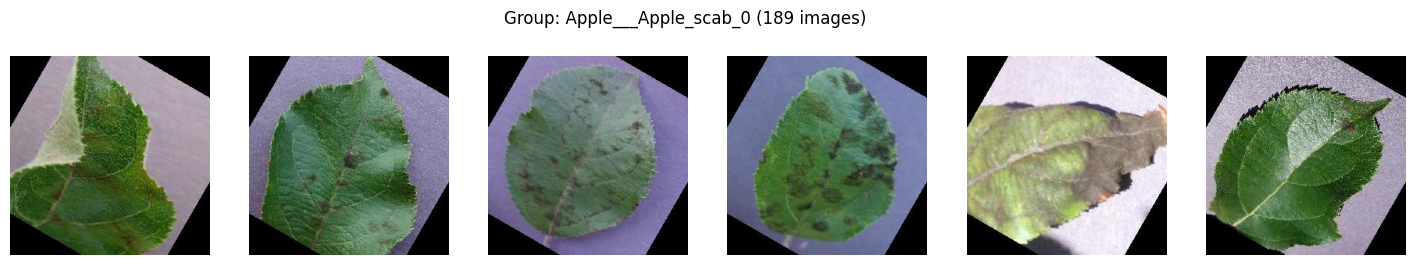

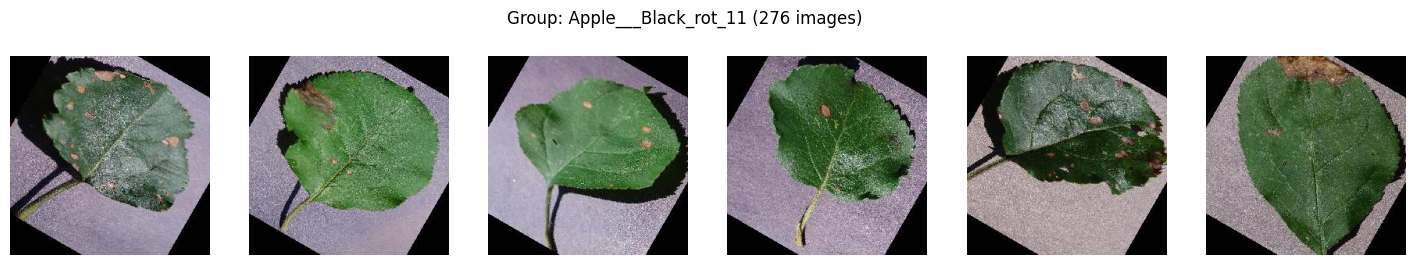

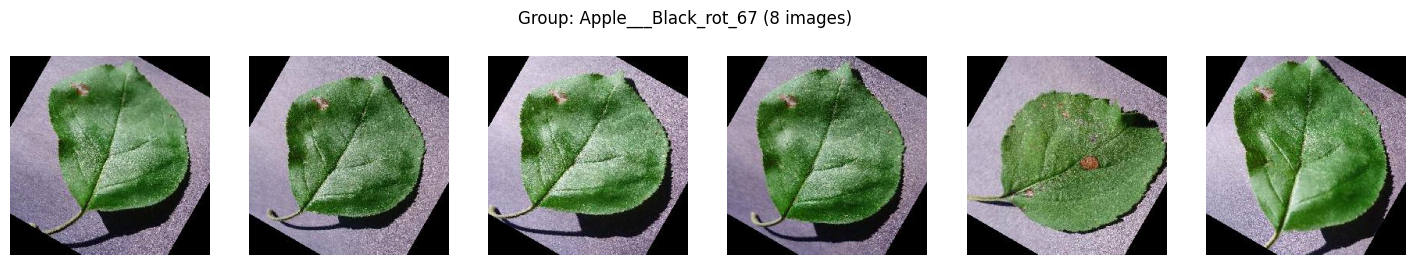

In [14]:
big_groups = df_clean.groupby("group_id").size()
big_groups = big_groups[big_groups >= 8].index[:3]

for g in big_groups:
    paths = df_clean[df_clean["group_id"] == g]["path"].tolist()
    fig, axes = plt.subplots(1, min(len(paths), 6), figsize=(18, 3))
    for ax, p in zip(axes, paths[:6]):
        ax.imshow(Image.open(p))
        ax.axis("off")
    plt.suptitle(f"Group: {g} ({len(paths)} images)")
    plt.show()

reducing hamming distance 


In [15]:
test_sub = df_clean[df_clean["label"] == "Apple___Apple_scab"]
gmap = group_by_similarity(test_sub, threshold=5)
sizes = pd.Series(gmap).value_counts()
print(sizes.value_counts())

# Visually check the biggest group again
df_clean.loc[test_sub.index, "group_id"] = test_sub.index.map(gmap)
big = df_clean.loc[test_sub.index].groupby("group_id").size().sort_values(ascending=False)
print(big.head())

count
1    2499
2       9
3       1
Name: count, dtype: int64
group_id
Apple___Apple_scab_1595    3
Apple___Apple_scab_1192    2
Apple___Apple_scab_144     2
Apple___Apple_scab_236     2
Apple___Apple_scab_670     2
dtype: int64


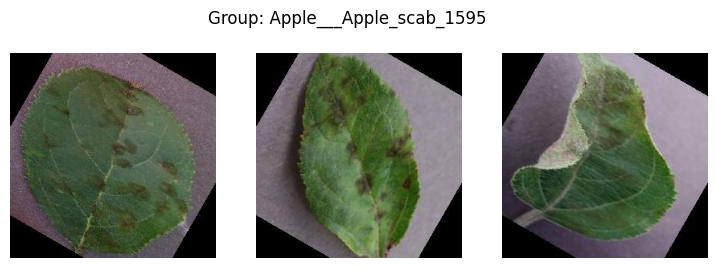

In [16]:
g = "Apple___Apple_scab_1595"
paths = df_clean[df_clean["group_id"] == g]["path"].tolist()
fig, axes = plt.subplots(1, len(paths), figsize=(len(paths)*3, 3))
for ax, p in zip(axes, paths):
    ax.imshow(Image.open(p))
    ax.axis("off")
plt.suptitle(f"Group: {g}")
plt.show()

In [17]:
from pathlib import Path

sample_names = df_clean[df_clean["label"] == "Apple___Apple_scab"]["path"].apply(lambda p: Path(p).name).head(30)
print(sample_names.tolist())

['c4e2b47d-d3c9-418e-9e60-78cead67c5d7___FREC_Scab 2928_new30degFlipLR.JPG', '9555b45b-0080-4d26-8b54-a343b9bf0ffc___FREC_Scab 3313_90deg.JPG', '5a178d63-372d-48c4-adb8-d616130ba3f0___FREC_Scab 3104.JPG', '0a6812de-7416-4ffe-aba9-307599a02c84___FREC_Scab 2973_270deg.JPG', '6b5e1187-9b7b-4b4c-912f-b2175619f35f___FREC_Scab 3121_90deg.JPG', '9f76829c-655e-4f75-b5fd-2ddfd01f963a___FREC_Scab 3337_new30degFlipLR.JPG', 'c7dc7cfa-559a-4950-ba71-90d11dfe0b56___FREC_Scab 3381_270deg.JPG', '1a21aabb-6f74-4644-8d9e-a517568b7e9c___FREC_Scab 3095_270deg.JPG', '8c5418d9-37db-450f-a20e-7fccfe69f57a___FREC_Scab 3404_new30degFlipLR.JPG', 'ade2b601-d2ea-4f5b-afc2-2c88aefea6b6___FREC_Scab 3464_new30degFlipLR.JPG', '35fde58e-46ea-4d1b-9580-ead7a2d0cb3b___FREC_Scab 2952_new30degFlipLR.JPG', '4b51cc5d-4122-451b-8598-81ea29dc7cd4___FREC_Scab 3290_90deg.JPG', '8bcbb4fb-c733-4fc7-92d2-6e4a442e592e___FREC_Scab 3506.JPG', '62c3478f-3ab0-48df-962f-9d7782ec364d___FREC_Scab 2925_90deg.JPG', '7e64fdef-9cb7-40ed-9f40-

In [18]:
import re

def extract_base_id(filename):
    # Remove extension
    name = Path(filename).stem
    # Pattern: <uuid>___<class_code> <number>[_<transform>]
    # We want everything up to and including the number, dropping any trailing transform suffix
    match = re.match(r"^(.*?\s\d+)", name)
    if match:
        return match.group(1)
    return name  # fallback: use full name if pattern doesn't match

# Test it
test_names = df_clean[df_clean["label"] == "Apple___Apple_scab"]["path"].apply(lambda p: Path(p).name)
test_base_ids = test_names.apply(extract_base_id)

print(test_names.head(10).tolist())
print(test_base_ids.head(10).tolist())

['c4e2b47d-d3c9-418e-9e60-78cead67c5d7___FREC_Scab 2928_new30degFlipLR.JPG', '9555b45b-0080-4d26-8b54-a343b9bf0ffc___FREC_Scab 3313_90deg.JPG', '5a178d63-372d-48c4-adb8-d616130ba3f0___FREC_Scab 3104.JPG', '0a6812de-7416-4ffe-aba9-307599a02c84___FREC_Scab 2973_270deg.JPG', '6b5e1187-9b7b-4b4c-912f-b2175619f35f___FREC_Scab 3121_90deg.JPG', '9f76829c-655e-4f75-b5fd-2ddfd01f963a___FREC_Scab 3337_new30degFlipLR.JPG', 'c7dc7cfa-559a-4950-ba71-90d11dfe0b56___FREC_Scab 3381_270deg.JPG', '1a21aabb-6f74-4644-8d9e-a517568b7e9c___FREC_Scab 3095_270deg.JPG', '8c5418d9-37db-450f-a20e-7fccfe69f57a___FREC_Scab 3404_new30degFlipLR.JPG', 'ade2b601-d2ea-4f5b-afc2-2c88aefea6b6___FREC_Scab 3464_new30degFlipLR.JPG']
['c4e2b47d-d3c9-418e-9e60-78cead67c5d7___FREC_Scab 2928', '9555b45b-0080-4d26-8b54-a343b9bf0ffc___FREC_Scab 3313', '5a178d63-372d-48c4-adb8-d616130ba3f0___FREC_Scab 3104', '0a6812de-7416-4ffe-aba9-307599a02c84___FREC_Scab 2973', '6b5e1187-9b7b-4b4c-912f-b2175619f35f___FREC_Scab 3121', '9f76829c-

In [19]:
df_clean["group_id"] = df_clean["path"].apply(lambda p: extract_base_id(Path(p).name))

group_sizes = df_clean.groupby("group_id").size()
print("Total unique groups:", group_sizes.nunique())
print(group_sizes.value_counts().head(15))

Total unique groups: 8
1     26014
2      9394
3      5390
4      1764
5      1747
6      1104
8       275
15      152
Name: count, dtype: int64


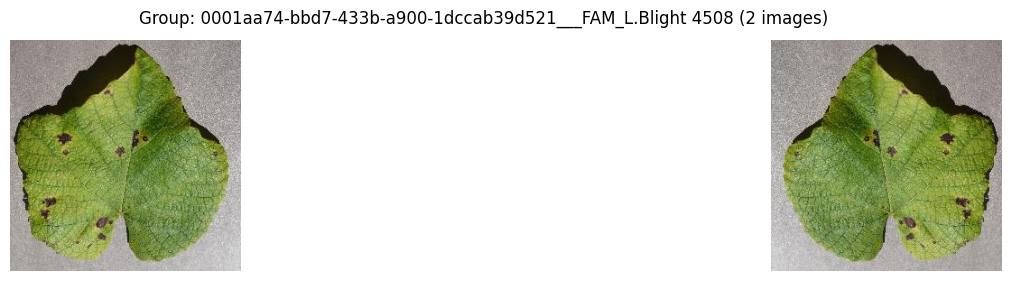

In [20]:
big_group = group_sizes[group_sizes > 1].index[0]
paths = df_clean[df_clean["group_id"] == big_group]["path"].tolist()
fig, axes = plt.subplots(1, min(len(paths), 6), figsize=(18, 3))
for ax, p in zip(axes, paths[:6]):
    ax.imshow(Image.open(p))
    ax.axis("off")
plt.suptitle(f"Group: {big_group} ({len(paths)} images)")
plt.show()

In [21]:
df_clean.to_csv("/kaggle/working/metadata_with_groups.csv", index=False)

In [22]:
from sklearn.model_selection import GroupShuffleSplit

# Split 1: train+val vs test (85/15)
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
trainval_idx, test_idx = next(gss1.split(df_clean, groups=df_clean["group_id"]))
trainval_df = df_clean.iloc[trainval_idx]
test_df = df_clean.iloc[test_idx]

# Split 2: train vs val (from trainval, ~82/18 → ~70/15 of total)
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.176, random_state=42)
train_idx, val_idx = next(gss2.split(trainval_df, groups=trainval_df["group_id"]))
train_df = trainval_df.iloc[train_idx]
val_df = trainval_df.iloc[val_idx]

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 61405
Val: 13259
Test: 13203


In [23]:
train_groups = set(train_df["group_id"])
val_groups = set(val_df["group_id"])
test_groups = set(test_df["group_id"])

print("Train-Val overlap:", len(train_groups & val_groups))
print("Train-Test overlap:", len(train_groups & test_groups))
print("Val-Test overlap:", len(val_groups & test_groups))

Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0


In [24]:
print(train_df["label"].value_counts(normalize=True).head())
print(test_df["label"].value_counts(normalize=True).head())

label
Potato___healthy                            0.028825
Soybean___healthy                           0.028792
Orange___Haunglongbing_(Citrus_greening)    0.028760
Apple___healthy                             0.028711
Tomato___Tomato_Yellow_Leaf_Curl_Virus      0.028516
Name: proportion, dtype: float64
label
Corn_(maize)___Northern_Leaf_Blight         0.032114
Apple___Apple_scab                          0.031811
Potato___Early_blight                       0.031357
Apple___healthy                             0.029917
Orange___Haunglongbing_(Citrus_greening)    0.029917
Name: proportion, dtype: float64


In [25]:
train_df.to_csv("/kaggle/working/train.csv", index=False)
val_df.to_csv("/kaggle/working/val.csv", index=False)
test_df.to_csv("/kaggle/working/test.csv", index=False)